In [ ]:
import pandas as pd
import numpy as np
from sentence_transformers import InputExample, SentenceTransformer, losses
from torch.utils.data import DataLoader
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

c:\Users\marko\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv("dataset_libros.csv")

# Crea ejemplos por pares (anchor, positivo)
train_examples = []
for autor in df['autor'].unique():
    textos = df[df['autor'] == autor]['fragmento'].tolist()
    for i in range(len(textos) - 1):
        train_examples.append(InputExample(texts=[textos[i], textos[i+1]]))

train_dataloader = DataLoader(train_examples, shuffle=True, batch_size=16)

# 2. Carga modelo base
model = SentenceTransformer("sentence-transformers/distiluse-base-multilingual-cased-v2")

# 3. Congela capas (solo entrenar las últimas)
for name, param in model.named_parameters():
    if not any(layer in name for layer in ["transformer.layer.4", "transformer.layer.5"]):
        param.requires_grad = False

# 4. Pérdida contrastiva
train_loss = losses.MultipleNegativesRankingLoss(model)

# 5. Entrenamiento
model.fit(
    train_objectives=[(train_dataloader, train_loss)],
    epochs=4,
    warmup_steps=100,
    output_path="./modelo_contrastivo_autores"
)

c:\Users\marko\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Step,Training Loss
500,2.361800
1000,1.905500


In [3]:
# Codificar labels
le = LabelEncoder()
y = le.fit_transform(df["autor"])

# Obtener embeddings del modelo
X = model.encode(df["fragmento"].tolist(), show_progress_bar=True)

# Dividir
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2)

# Entrenar clasificador
clf = LogisticRegression(max_iter=2000)
clf.fit(X_train, y_train)

# Evaluar
print("Accuracy:", clf.score(X_test, y_test))


def predecir_autor(fragmento):
    emb = model.encode([fragmento])
    probs = clf.predict_proba(emb)[0]
    sim_matrix = cosine_similarity(emb, X_train)
    max_sim = np.max(sim_matrix)
    
    if max_sim < 0.65:  # Umbral configurable
        print("Autor desconocido. Los más similares:")
        similar_idxs = np.argsort(-sim_matrix[0])[:3]
        for i in similar_idxs:
            print("-", le.inverse_transform([y_train[i]])[0])
    else:
        autor_pred = le.inverse_transform([np.argmax(probs)])[0]
        print(f"Autor probable: {autor_pred}")
        print("Probabilidades:", dict(zip(le.classes_, probs)))

Batches: 100%|██████████| 153/153 [05:11<00:00,  2.04s/it]


Accuracy: 0.8761514841351075


Accuracy: 0.874439461883408

In [4]:
predecir_autor(" protegido por el relicario de su madre colgado al cuello, pero para qué ir tan atrás, basta decir que su descendencia fue una estirpe de mujeres impetuosas y hombres de brazos firmes para el trabajo y corazón sentimental.") 

Autor probable: Isabel Allende
Probabilidades: {'Carlos Ruiz Zafón': 0.0005883591029629678, 'Eloy Moreno': 0.0012682613404756107, 'Isabel Allende': 0.7788583383033011, 'Javier Castillo': 0.00605879168744164, 'María Dueñas': 0.19132122711750954, 'Santiago Posteguillo': 0.02190502244830905}


Autor probable: Isabel Allende
Probabilidades: {'Carlos Ruiz Zafón': 0.004892432974233211, 'Eloy Moreno': 0.0009057715817119228, 'Isabel Allende': 0.6798013951701075, 'Javier Castillo': 0.029312926184460134, 'María Dueñas': 0.25201712631814094, 'Santiago Posteugillo': 0.03307034777134639}

In [5]:
predecir_autor("Los primeros días fueron los peores: sumergida en el almacén, intentando encontrar un hilo de congruencia entre las tripas de aquel caos donde las docenas de cuadernos se mezclaban con montones de folios escritos a dos caras, con cientos de paquetes de cuartillas amarillentas y un número infinito de cartas y tarjetas alborotadas. Todo esparcido por el suelo, arrumbado en montones contra la pared, en estantes que amenazaban con desplomarse y en pilas desequilibradas al borde del tambaleo.")

Autor probable: Javier Castillo
Probabilidades: {'Carlos Ruiz Zafón': 0.09691147572162172, 'Eloy Moreno': 0.06893260664351414, 'Isabel Allende': 0.029038095395358135, 'Javier Castillo': 0.6537988456613272, 'María Dueñas': 0.14775261510318502, 'Santiago Posteguillo': 0.0035663614749937332}


Autor probable: María Dueñas
Probabilidades: {'Carlos Ruiz Zafón': 0.16997172172837532, 'Eloy Moreno': 0.03317507723648371, 'Isabel Allende': 0.10587716504222064, 'Javier Castillo': 0.2730769833658386, 'María Dueñas': 0.40840373231816013, 'Santiago Posteugillo': 0.009495320308921735}

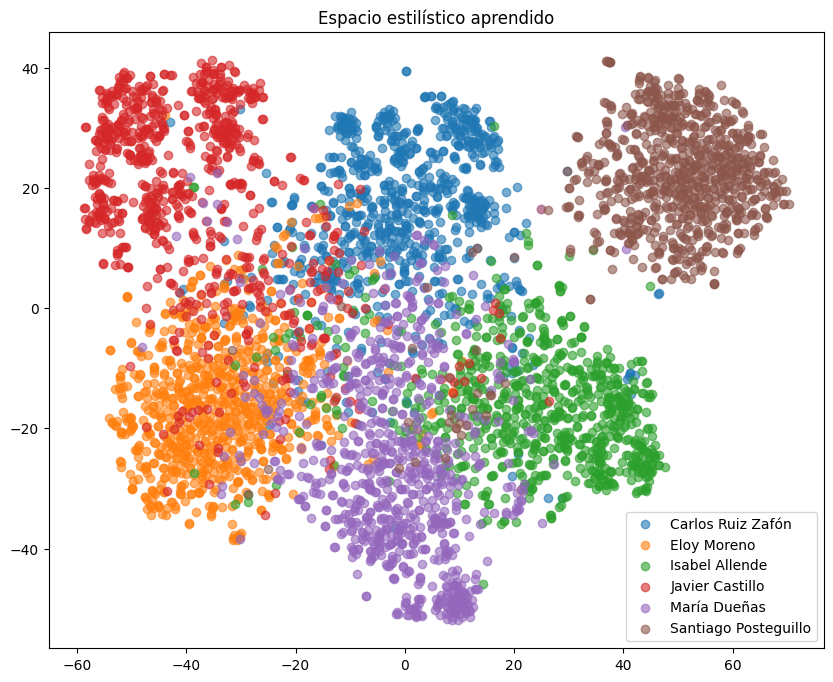

In [6]:
tsne = TSNE(n_components=2, random_state=42)
X_2d = tsne.fit_transform(X)

plt.figure(figsize=(10,8))
for autor in le.classes_:
    idxs = (df["autor"] == autor)
    plt.scatter(X_2d[idxs,0], X_2d[idxs,1], label=autor, alpha=0.6)
plt.legend()
plt.title("Espacio estilístico aprendido")
plt.show()